In [ ]:
#pip install pyspark
pip install pandas

In [2]:
# Importando as bibliotecas
from pyspark.sql import SparkSession

# Inicializando a sessão
spark = SparkSession.builder \
    .appName("spark") \
    .master("local") \
    .getOrCreate()

# Definindo o nível do log
spark.sparkContext.setLogLevel("ERROR")

# Obtendo o SparkContext da SparkSession
sc = spark.sparkContext

# Imprimindo as informações do SparkContext
print("Spark version:", sc.version)
print("Python version:", sc.pythonVer)
print("Master URL:", sc.master)
print("Spark home:", str(sc.sparkHome))
print("Spark user:", str(sc.sparkUser()))
print("Application name:", sc.appName)
print("Application ID:", sc.applicationId)
print("Default parallelism:", sc.defaultParallelism)
print("Default minimum partitions:", sc.defaultMinPartitions)

Spark version: 3.5.7
Python version: 3.11
Master URL: local[*]
Spark home: None
Spark user: jovyan
Application name: Benchmark-Formats
Application ID: local-1760826181868
Default parallelism: 12
Default minimum partitions: 2


In [2]:
if spark:
    spark.stop()

In [27]:
import time, os, json
from pyspark.sql import SparkSession

# =====================================================
# Sessão Spark
# =====================================================
spark = (
    SparkSession.builder
    .appName("Benchmark-Formats")
    .master("local[*]")
    .config("spark.executor.memory", "1g")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config("spark.hadoop.fs.s3a.path.style.access", "true")
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "true")
    .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000")
    .config("spark.hadoop.fs.s3a.access.key", "minioadmin")
    .config("spark.hadoop.fs.s3a.secret.key", "minioadmin")
    .config("spark.hadoop.fs.s3a.committer.name", "directory")
    .getOrCreate()
)
sc = spark.sparkContext
sc.setLogLevel("ERROR")

# =====================================================
# Dataset base (local CSV)
# =====================================================
schema = "raceId INT, driverId INT, lap INT, position INT, time STRING, milliseconds INT"
df = spark.read.csv("/home/jovyan/data/lap_times.csv", header=True, schema=schema) #.limit(20) # -- Para limitar a quantidade de dados
print("Linhas carregadas:", df.count())

# =====================================================
# Funções auxiliares
# =====================================================
def medir_tempo(op, label):
    inicio = time.time()
    result = op()
    fim = time.time()
    print(f"{label}: {fim - inicio:.2f}s")
    return fim - inicio, result

def medir_leitura(fmt, path):
    inicio = time.time()
    if fmt == "csv":
        df = spark.read.option("header", True).csv(path)
    elif fmt == "json":
        df = spark.read.json(path)
    elif fmt == "parquet":
        df = spark.read.parquet(path)
    elif fmt == "avro":
        df = spark.read.format("avro").option("ignoreExtension", "true").load(path)
    elif fmt == "orc":
        df = spark.read.orc(path)
    linhas = df.count()
    fim = time.time()
    return fim - inicio, linhas

# =====================================================
# Escrita em diferentes formatos no MinIO
# =====================================================
base = "s3a://datalake/lap_times_"
formats = ["csv", "json", "parquet", "avro", "orc"]
tempos_escrita = {}
for fmt in formats:
    path = base + fmt
    print(f"Gravando {fmt.upper()} -> {path}")
    inicio = time.time()
    if fmt == "csv":
        df.write.mode("overwrite").option("header", True).csv(path)
    elif fmt == "json":
        df.write.mode("overwrite").json(path)
    elif fmt == "parquet":
        df.write.mode("overwrite").parquet(path)
    elif fmt == "avro":
        df.write.mode("overwrite").format("avro").save(path)
    elif fmt == "orc":
        df.write.mode("overwrite").orc(path)
    fim = time.time()
    tempos_escrita[fmt] = round(fim - inicio, 2)
    print(f"→ Tempo de escrita {fmt.upper()}: {tempos_escrita[fmt]}s")

# =====================================================
# Verifica tamanhos com mc (precisa alias 'local')
# =====================================================
!mc alias set local http://minio:9000 minioadmin minioadmin >/dev/null
tamanhos = {}
for fmt in formats:
    info = os.popen(f"mc du --json local/datalake/lap_times_{fmt}/").read()
    try:
        tamanho = float(json.loads(info)["size"]) / (1024 * 1024)
    except:
        tamanho = 0
    tamanhos[fmt] = round(tamanho, 2)

# =====================================================
# Leitura e benchmark
# =====================================================
tempos_leitura = {}
linhas_lidas = {}
for fmt in formats:
    path = base + fmt
    try:
        tempo, linhas = medir_leitura(fmt, path)
        tempos_leitura[fmt] = round(tempo, 2)
        linhas_lidas[fmt] = linhas
        print(f"{fmt.upper()}: {linhas} linhas em {tempo:.2f}s")
    except Exception as e:
        tempos_leitura[fmt] = None
        linhas_lidas[fmt] = 0
        print(f"Erro ao ler {fmt}: {e}")

# =====================================================
# Resultado consolidado
# =====================================================
print("\n=== RESULTADO FINAL ===")
print(f"{'Formato':<10} {'Tamanho (MB)':>12} {'Escrita (s)':>12} {'Leitura (s)':>12} {'Linhas':>10}")
for fmt in formats:
    print(f"{fmt.upper():<10} {tamanhos[fmt]:>12.2f} {tempos_escrita[fmt]:>12.2f} {tempos_leitura[fmt] or 0:>12.2f} {linhas_lidas[fmt]:>10}")

Linhas carregadas: 551742
Gravando CSV -> s3a://datalake/lap_times_csv
→ Tempo de escrita CSV: 0.62s
Gravando JSON -> s3a://datalake/lap_times_json
→ Tempo de escrita JSON: 0.58s
Gravando PARQUET -> s3a://datalake/lap_times_parquet
→ Tempo de escrita PARQUET: 0.76s
Gravando AVRO -> s3a://datalake/lap_times_avro
→ Tempo de escrita AVRO: 0.42s
Gravando ORC -> s3a://datalake/lap_times_orc
→ Tempo de escrita ORC: 0.51s
CSV: 551742 linhas em 0.20s
JSON: 551742 linhas em 0.46s
PARQUET: 551742 linhas em 0.12s
AVRO: 551742 linhas em 0.21s
ORC: 551742 linhas em 0.09s

=== RESULTADO FINAL ===
Formato    Tamanho (MB)  Escrita (s)  Leitura (s)     Linhas
CSV               14.65         0.62         0.20     551742
JSON              47.80         0.58         0.46     551742
PARQUET            4.37         0.76         0.12     551742
AVRO               7.34         0.42         0.21     551742
ORC                4.19         0.51         0.09     551742


In [31]:
# Adicionar os resultados em um dicionario python
data = {}
data['Formato'] = []
for fmt in formats: data['Formato'].append(fmt.upper())
varsBench = ["Tamanho_MB", "Escrita_s", "Leitura_s"]
for var in varsBench: 
    data[var] = []
    for fmt in formats:
        if(var == varsBench[0]): data[var].append(tamanhos[fmt])
        elif(var == varsBench[1]): data[var].append(tempos_escrita[fmt])
        else: data[var].append(tempos_leitura[fmt])
print(data)

{'Formato': ['CSV', 'JSON', 'PARQUET', 'AVRO', 'ORC'], 'Tamanho_MB': [14.65, 47.8, 4.37, 7.34, 4.19], 'Escrita_s': [0.62, 0.58, 0.76, 0.42, 0.51], 'Leitura_s': [0.2, 0.46, 0.12, 0.21, 0.09]}


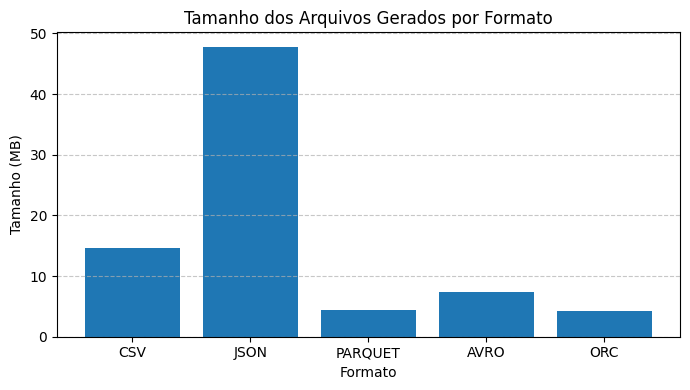

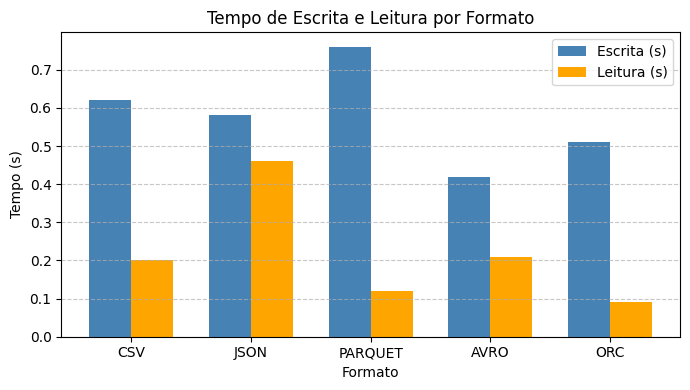

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# Dados obtidos no benchmark exemplo
'''
data = {
    "Formato": ["CSV", "JSON", "PARQUET", "AVRO", "ORC"],
    "Tamanho_MB": [14.65, 47.80, 4.37, 7.34, 4.19],
    "Escrita_s": [2.37, 1.07, 1.99, 0.98, 1.24],
    "Leitura_s": [1.31, 2.01, 0.35, 0.73, 0.23]
}
'''

df = pd.DataFrame(data)

# --- Gráfico 1: Tamanho ---
plt.figure(figsize=(7,4))
plt.bar(df["Formato"], df["Tamanho_MB"])
plt.title("Tamanho dos Arquivos Gerados por Formato")
plt.ylabel("Tamanho (MB)")
plt.xlabel("Formato")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Gráfico 2: Tempo de Escrita vs Leitura ---
plt.figure(figsize=(7,4))
bar_width = 0.35
x = range(len(df))

plt.bar(x, df["Escrita_s"], width=bar_width, label="Escrita (s)", color="steelblue")
plt.bar([p + bar_width for p in x], df["Leitura_s"], width=bar_width, label="Leitura (s)", color="orange")

plt.xticks([p + bar_width/2 for p in x], df["Formato"])
plt.title("Tempo de Escrita e Leitura por Formato")
plt.ylabel("Tempo (s)")
plt.xlabel("Formato")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
'''
- Workload analítico, ou Online Analytical Processing (OLAP), é uma tecnologia para performar consultas complexas em alta velocidade ou análise multidimensional em
grandes volumes de dados, divididos entre um ou mais cubos, uma base de dados multidimensional baseada em array que permite processar e analisar vários dados em 
múltiplas dimensões muito mais rápidamente e eficiente que uma base de dados relacional tradicional.
- Streaming é um processo de fluxo contínuo de dados em tempo real de diversas origens, onde os dados são processados imediatamente após chegarem. Por causa do fluxo
contínuo, estratégias de streaming precisam de diferentes tipos de processamento do que processamento em lotes, incluindo arquiteturas escaláveis e processadores de
fluxo que manejam ingestão de dados, processamento e análise enquanto mantém um performance ótima.

Com os dados que obtemos, é possível definir quais formatos são os melhores para Workloads analíticos, e quais são melhores para Streaming, porém primeiramente
devemos conhecer o que cada formato de arquivo faz e no que eles se especializam.

1. CSV = Simples é o seu nome. Um arquivo de texto simples delimitado por separadores, geralmente vírgulas, e permite que se crie planilhas e tabelas a partir de linhas
e colunas para separar os dados em categorias. O CSV é um formato popular bem conhecido por sua simplicidade, sendo primariamente utilizado para armazenar dados
tabulares (dados que possam ser decompostos entre linhas e colunas).
    Vantagens:
        - Simplicidade: fácil de se criar, pois é um formato primariamente legível para humanos, podendo ser criado e lido com qualquer editor de texto
        - Fácil integração: esse formato permite um analizador simples de arquivos, facilitando a integração em outros códigos
    Desvantagens:
        - Não criptografado: por sua natureza simples, o csv não foca na criptografia dos dados, podendo deixar a desejar na questão de segurança dos dados
        - Baixa flexibilidade: sua natureza não permite que os dados possuam variáveis próprias, sendo necessário adicionar uma coluna a mais para todos os dados
        - Ineficiência de memória: os programas tem que analizar os dados de um a um para achar um determinado dado, o tornando ineficiente em memória

2. JSON = O nome vem de "JavaScript Object Notation", criado para servir como uma extensão da sintaxe do JavaScript para envio de dados entre aplicativos da Web e um
servidor. Ele é um arquivo de texto baseado em objetos de chave-valor, em que cada linha contém um objeto JSON independente, não se limitando a valores fixos, 
fazendo esse ser um formato leve, altamente flexível e fácil de ler e escrever.
    Vantagens:
        - Simplicidade: sintaxe baseada em objetos chave-valor, facilitando a leitura e escrita tanto para humanos quanto para máquinas.
        - Compatibilidade: o formato é independente da linguagem de programação, o que significa que pode facilmente ser interpretado por várias linguagens.
        - Suporte nativo ao JavaScript: permite uma integração natural a aplicações JavaScript, facilitando o desenvolvimento de armazenamento Web
        - Alta flexibilidade: o JSON usa estruturas hierárquicas, permitindo a representação de dados complexos de forma organizada e aninhada, contribuindo para 
            amodelagem de informações mais detalhadas
    Desvantagens:
        - Redundância de dados: o formato pode se tornar redundante em casos com repetição frequente de dados, o que faz o arquivo ser grande e impactando no desempenho
        - Limitação de dados: ele não é bom para armazenar dados binários, como imagens ou arquivos compactados, necessitando condições adicionais
        - Falha na manipulação de grandes conjunto de dados: devido ao seu tamanho, o formato pode apresentar falhas em desempenho em conjuntos de dados grandes
            em comparação com outros formatos mais eficiêntes de espaço.

3. PARQUET = Ele é um formato de arquivo de dados binário colunar de código aberto projetado para armazenamento e recuperação de dados eficientes, que fornece esquemas
eficientes de compressão e codificação de dados para agrupar dados complexos com melhor desempenho, otimizado para consultas rápidas, compressão eficiente e
processamento em massa de dados complexos. Os dados são divididos em colunas comprimidas e com metadados embutidos, utilizando o padrão Snappy para compressão,
mas suporta GZIP, ZSTD, Brocoli e etc.
    Vantagens:
        - Variedade: ele consegue armazenar todos os tipos de dados, incluindo dados estruturados, tabelas, imagens, vídeos, documentos e muito mais.
        - Compacto: sua compactação por coluna é muito eficiente e os esquemas de codificação são flexíveis para colunas de diferentes tipos de dados.
        - Desempenho: ele usa técnicas como salto de dados para não precisar ler diversas linhas de dados para recuperar valores em colunas específicas.
        - Seguro: Ele oferece esquemas eficientes para criptografia dos dados, o que melhora a segurança deles.
        - Compatibilidade: ele é compatível com diversas ferramentas de big data, incluindo o Apache Spark, Apache Hive e Apache Impala
    Desvantagens:
        - Alto uso de CPU: Sua eficiência de habilidades compressão podem levar a alto uso da CPU, que pode impactar a performance em alguns casos.
        - Performance baixa em escritas: Devido à sua naturesa colunar, parecido com o CSV, a escrita de dados pode ser mais devagar do que outras ações.
        - Baixa legibilidade humana: Os dados são armazenados em binário, portanto a leitura manual dos dados pode ser mais complicada para um humano.

4. AVRO: Ele é um formato de dados binário baseado em linhas usando o JSON como esquema de armazenamento. Ele processa os dados de forma eficiente, lida com
armazenamento e recuperação de dados, ajuda a capturar erros rapidamente, priorizando velocidade e acurácia sobre o tempo enquanto suporta requisitos
exigentes de ambientes de processamento de dados contemporâneos. é composto por dois componentes principais, o esquema e os dados serializados, onde o
primeiro define a estrutura dos dados, através de um cabeçalho JSON, e especifica os campos que eles contém, incluindo tipos de dados, nomes e relacionamentos
entre eles. 
    Vantagens:
        - Armazenamento linear: ele armazena os dados em um formato baseado em linha, que faz ele ser mais adequado a operacões pesadas de escritura, como
            streaming, em que precisa escrever os dados continuamente.
        - Serialização eficiente: possui um formato binário compacto para serialização, que é leve e eficiente tanto para armazenamento e transmissão entre redes
        - Evolução de esquema: Suporta evolução de esquemas, onde ele é armazenado com os dados, permitindo flexibilidade ao lidar com alterações
        - Compatibilidade: ele é compatível através diferentes linguagens, como Java e Python, sendo adequado com protocolos de comunicação como RPC
    Desvantagens:
        - Ineficiente para análises: ele performa mal para workloads analíticos onde você só precisa de algumas colunas devido a sua natureza baseada em linhas,
            necessitando que escaneie várias linhas para achar a coluna necessária.
        - Sem indexação nativa: ele não suporta indexação e armazenamento colunar, que pode ser uma desvantagem para consultas analíticas grandes
        - Predicate pushdown limitado: a função de filtrar os dados antes de recebê-los é limitado, afetando a performance

5. ORC: É um formato de armazenamento binário de dados de alta performance criado para o Hadoop e outros sistemas de processamento de big data. É um formato colunar
feito para melhorar processamento de dados e eficiência de armazenamento através de características avançadas, como compressão, indexação e predicate pushdown.
Organiza os dados em listras, em que cada linha é quebrada em pedaços que armazenam colunas específicas
    Vantagens: 
        - Eficiência: Por ser colunar, ele premite leituras eficientes para quando quiser apenas algumas colunas específicas.
        - Compacto: usa técnicas de compressão com codificações leves para melhor eficiência de armazenamento
        - Indexação e Predicate pushdown: ele suporta predicate pushdown e inclui indexação interna para maximizar a performance de consultas
        - Alta performance: tende a performar melhor do que o Parquet em certas operações devido à sua estrutura de armazenamento otimizada.
        - Otimizado para o Hadoop: Naturalmente integrado com o ecossistema do Hadoop e otimizado para leituras e escritas no sistema de arquivo distribuído do
            Hadoop (HDFS)
    Desvantagens:
        - Complexidade de escrita: Escrita de dados nesse formato tende a ser mais devagar que o Avro devido à necessidade de organizar os dados em forma de colunas
        - Tamanho de arquivos: Funciona melhor com arquivos grandes e pode sofrer degradações com muitos arquivos pequenos
        - Ecossistema limitado: Não tem muito suporte para várias ferramentas de big data que nem o Parquet, sendo primariamente suportado no ecossistema do Hadoop

    Através da análise dos dados obtidos, foi possível identificar que os formatos JSON e CSV foram os que menos tiveram eficiência em armazenamento devido a suas
naturezas simplistas e pouco suporte a técnicas de compressão. O formato JSON é bom quando os dados possuem muitas variáveis, necessitando alta flexibilidade, porém
ele não lida bem com dados com padrões bem definidos por causa da sua redundância de dados. O formato CSV é simplista demais para aplicações que necessitam uma melhor
flexibilidade nos dados e melhor eficiência de memória, também não sendo a melhor alternativa quando o assunto é transferência em massa de dados, sem contar que os
dois não possuem suporte a arquivos de dados binários, como imagens ou arquivos compactados.
    Sendo assim, resta 3 formatos para serem avaliados: Parquet, Avro e ORC. Os três possuíram melhor performance em eficiência de armazenamento, com o Parquet e o
ORC empatando com as melhores eficiências de armazenamento entre os testes. Esses dois possuem propostas similares, armazenando arquivos de dados no formato binário
de forma colunar, podendo armazenar qualquer tipos de arquivos. Através dos testes, foi possível identificar que o Parquet possui uma grande dificuldade em escrita
de arquivos do que o ORC, porém é necessário também ter em mente que o ORC possui um ecossistema limitado, sendo criado primariamente para o ecossistema do Hadoop,
podendo ser uma grande desvantagem dependendo da aplicação, enquanto o Parquet possui maior compatibilidade com outras ferramentas de big data. Vale notar também que
o Parquet pode possuir um alto uso de CPU do que o ORC devido a suas habilidades de compressão. Porém o ORC também tem outro ponto negativo forte, que ele é funciona
melhor com arquivos grandes, e pode sofrer degradações com diversos arquivos pequenos.
    O formato Avro utiliza uma formatação de dados binários em um formato linear, que otimiza a performance em operações pesadas de escritura, que é essencial para
estratégias de streaming. Não só isso, ele possui uma boa flexibilidade devido a sua forma de armazenar dados serializados com cabeçalhos JSON, é compatível com
diversas linguagens e eficiência de compactação de dados. Porém seus defeitos são que ele performa mal em workloads analíticos, não suporta indexação e possui um
predicate pushdown limitado. Esses pontos podem ser comprovados através da análise dos dados obtidos, em que ele possui o menor tempo de escrita entre todos os
formatos, porém velocidade leitura comparado ao CSV. O que faz esse formato ser mais focado para serviços de streaming, que necessitam velocidade superior de escrita
devido ao fluxo constante de dados.

    Portanto, é possível afirmar que o melhor formato de arquivo para estratégias de streaming de dados é o formato Avro, otimizado para escrita de arquivos binários
em alta performance, eficiência boa de armazenamento e boa flexibilidade dos dados, priorizando velocidade e acurácia sobre o tempo enquanto suporta requisitos
exigentes dos ambientes de processamento.
    Contudo, o melhor formato de arquivo para estratégias de Workload analíticos (OLAPs), depende de cada aplicação. Use o formato Parquet se precisar de uma
compatibilidade maior com outras ferramentas de big data e melhor eficiência com qualquer tamanho de dado, porém com maior uso da CPU e maior tempo de escrita, ou o
formato ORC, com altas eficiências de leitura, escrita e armazenamento para dados grandes e menos uso da CPU, porém com um ecossistema limitado ao Hadoop e menor
eficiência com diversos dados pequenos.
'''